In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import regionmask
import flox

In [ ]:
# setup
processed_dir = '../data/FASTMIP_phase2/METEOR_emulations/processed/'

ESM_list = ['ACCESS-ESM1-5','CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'MIROC6']  #(Tier 1 list)
scenario_list = ['SSP2 - Low Emissions', 'SSP2 - Medium Emissions', 'SSP3 - High Emissions', 'SSP1 - Very Low Emissions']
scenarios_short = ['L','M','H','VL']

# select model, variable (tas or pr), scenario, and grid-cell selection for plotting:
model = ESM_list[2]
plot_var = 'tas'
s_idx = 0 
sel_lat = 46.25
sel_lon = 3.75

if plot_var == 'tas':
    ylabel = 'Temperature (K)'
elif plot_var == 'pr':
    ylabel = 'Precipitation'

In [3]:
# global mean:
def glb_mean(ds):
    weights = np.cos(np.deg2rad(ds.lat))
    weights.name = "weights"
    glb_mean = ds.weighted(weights).mean(("lat", "lon"))
    return glb_mean

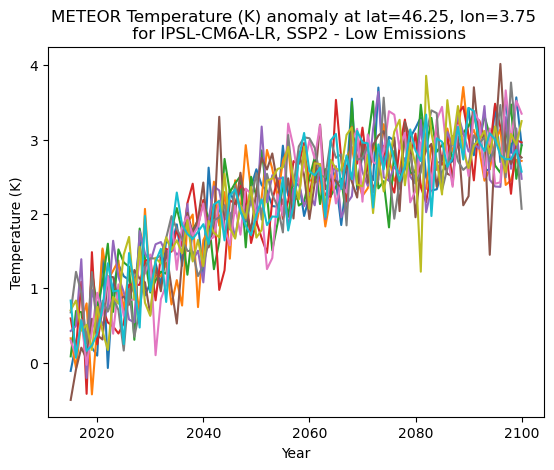

In [ ]:
# plot ensemble timeseries for a given point:
data = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_gridcell_selected-realisations.nc")

plt.figure()
plt.plot(data['year'].values, data[plot_var].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, method='nearest').values)
plt.xlabel('Year')
plt.ylabel(ylabel) 
plt.title(f'METEOR {ylabel} anomaly at lat={sel_lat}, lon={sel_lon} \n for {model}, {scenario_list[s_idx]}')
plt.show()


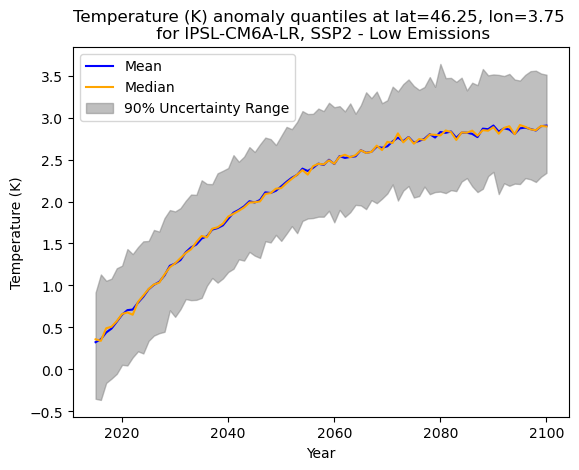

In [ ]:
# plotting the median and mean temperature anomaly
# along with the 90% uncertainty range for the selected grid-cell
example_data = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_gridcell_quantiles-by-ESM.nc")

plt.figure()
plt.plot(example_data['year'].values, example_data['tas_mean'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, method='nearest').values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, quantile=0.5, method='nearest').values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, quantile=0.05, method='nearest').values.squeeze(),
                 example_data['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, quantile=0.95, method='nearest').values.squeeze(),
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel(ylabel)  # Assuming the data is temperature in Kelvin
plt.title(f'{ylabel} anomaly quantiles at lat={sel_lat}, lon={sel_lon} \n for {model}, {scenario_list[s_idx]}')
plt.legend()
plt.show()


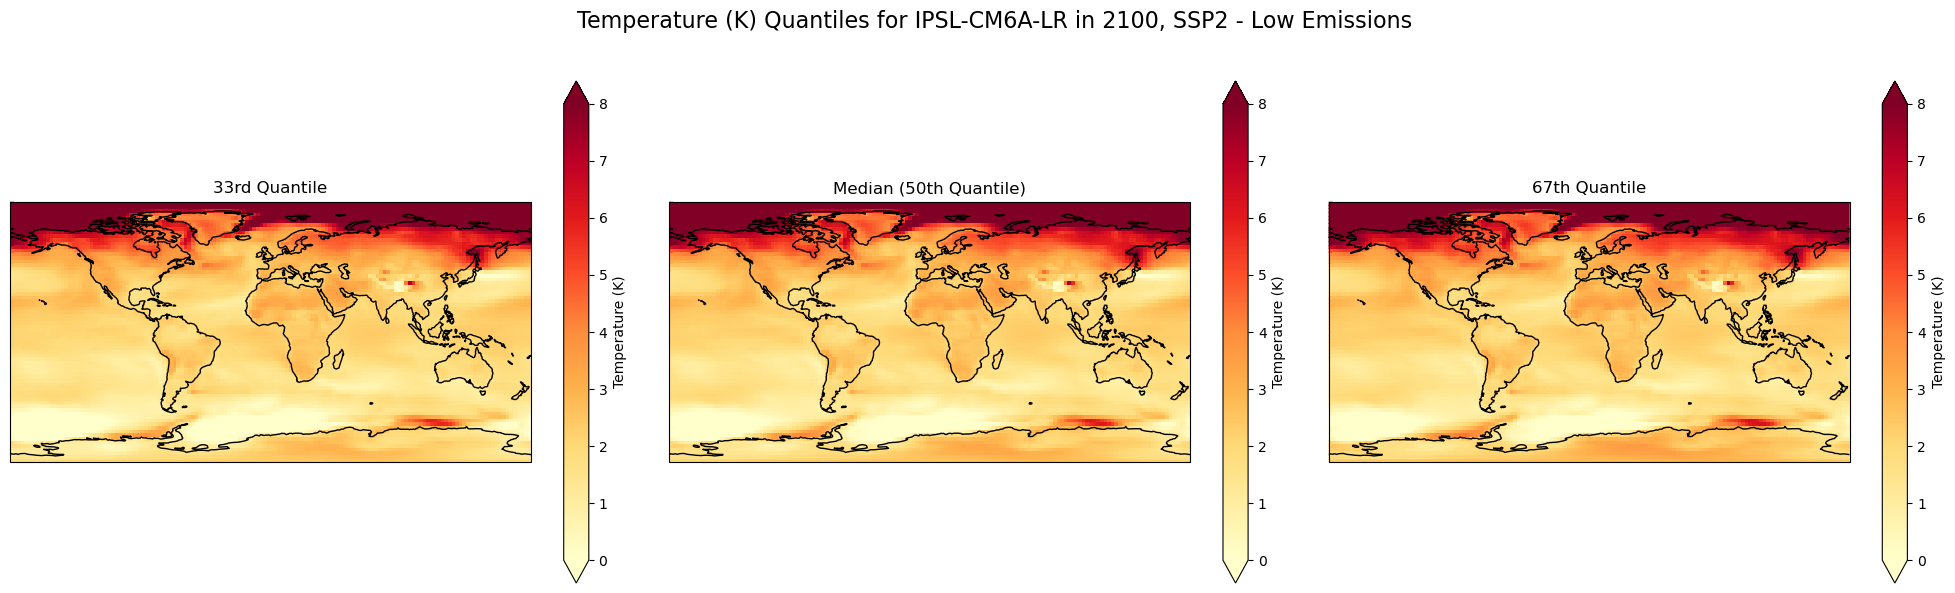

In [ ]:
# Generate maps for the 33rd, median, and 67th quantiles for the selected ESM and year 2100

quantiles_to_plot = [0.33, 0.5, 0.67]
titles = ['33rd Quantile', 'Median (50th Quantile)', '67th Quantile']
cmap = 'YlOrRd'

fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw={'projection': ccrs.PlateCarree()})

for ax, quantile, title in zip(axes, quantiles_to_plot, titles):
    data = example_data['tas'].sel(quantile=quantile, esm=model, year=2100)
    data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        cbar_kwargs={"label": ylabel},
        vmin = 0,
        vmax = 8
    )
    ax.coastlines()
    ax.set_title(title)

fig.suptitle(f'{ylabel} Quantiles for {model} in 2100, {scenario_list[s_idx]}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for the suptitle
plt.show()


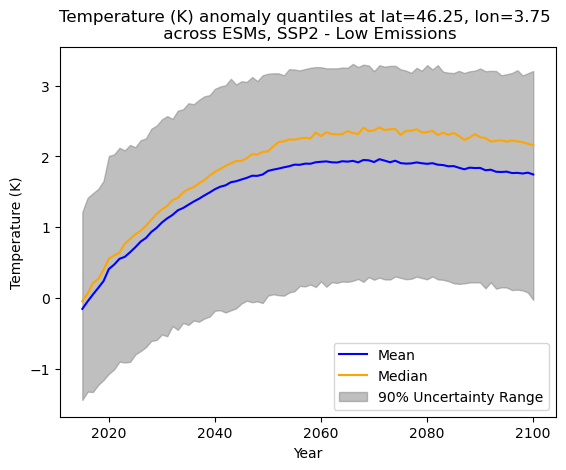

In [ ]:
# plot the median and mean temperature anomaly
# along with the 90% uncertainty range computed across ESMs
# for the selected grid-cell
example_data = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_gridcell_quantiles-across-ESM.nc")

plt.figure()
plt.plot(example_data['year'].values, example_data[f'{plot_var}_mean'].sel(lat=sel_lat, lon=sel_lon, method='nearest').values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data[plot_var].sel(lat=sel_lat, lon=sel_lon, quantile=0.5, method='nearest').values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data[plot_var].sel(lat=sel_lat, lon=sel_lon, quantile=0.05, method='nearest').values,
                 example_data[plot_var].sel(lat=sel_lat, lon=sel_lon, quantile=0.95, method='nearest').values,
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel(ylabel)  # Assuming the data is temperature in Kelvin
plt.title(f'{ylabel} anomaly quantiles at lat={sel_lat}, lon={sel_lon} \n across ESMs, {scenario_list[s_idx]}')
plt.legend()
plt.show()


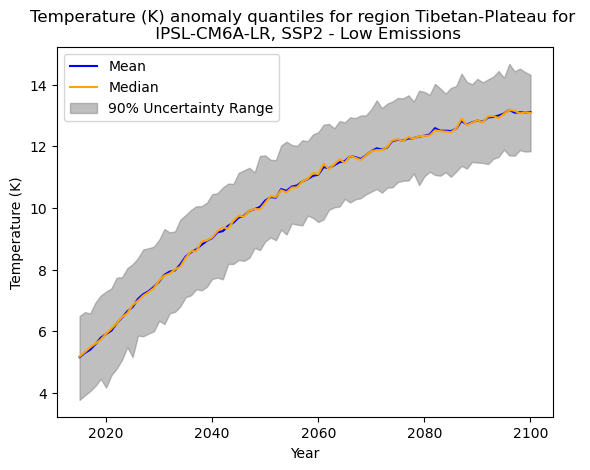

In [ ]:
# plot the median and mean temperature anomaly
# along with the 90% uncertainty range for a selected region
# and ESM
example_data = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_regional_quantiles-by-ESM.nc")
selected_regions = [-1, 34, 17]
sel_mask = selected_regions[1]  # selecting a region
region_name = regionmask.defined_regions.ar6.land[sel_mask].name # getting the name of the region

plt.figure()
plt.plot(example_data['year'].values, example_data[f'{plot_var}_mean'].sel(mask = sel_mask, esm = model ).values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data[plot_var].sel(mask = sel_mask, quantile=0.5, esm = model ).values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data[plot_var].sel(mask = sel_mask, quantile=0.05, esm = model ).values,
                 example_data[plot_var].sel(mask = sel_mask, quantile=0.95, esm = model ).values,
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel(ylabel)  # Assuming the data is temperature in Kelvin
plt.title(f'{ylabel} anomaly quantiles for region {region_name} for \n {model}, {scenario_list[s_idx]}')
plt.legend()
plt.show()


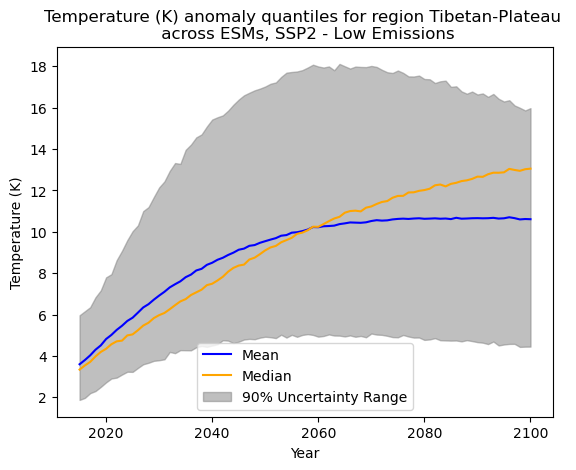

In [ ]:
# plot the median and mean temperature anomaly
# along with the 90% uncertainty range for a selected region
# across ESMs
example_data = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_regional_quantiles-across-ESM.nc")
sel_mask = selected_regions[1]  # selecting a region
region_name = regionmask.defined_regions.ar6.land[sel_mask].name # getting the name of the region

plt.figure()
plt.plot(example_data['year'].values, example_data[f'{plot_var}_mean'].sel(mask = sel_mask).values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data[f'{plot_var}'].sel(mask = sel_mask, quantile=0.5).values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data[f'{plot_var}'].sel(mask = sel_mask, quantile=0.05).values,
                 example_data[f'{plot_var}'].sel(mask = sel_mask, quantile=0.95).values,
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel(ylabel)  # Assuming the data is temperature in Kelvin
plt.title(f'{ylabel} anomaly quantiles for region {region_name} \n across ESMs, {scenario_list[s_idx]}')
plt.legend()
plt.show()


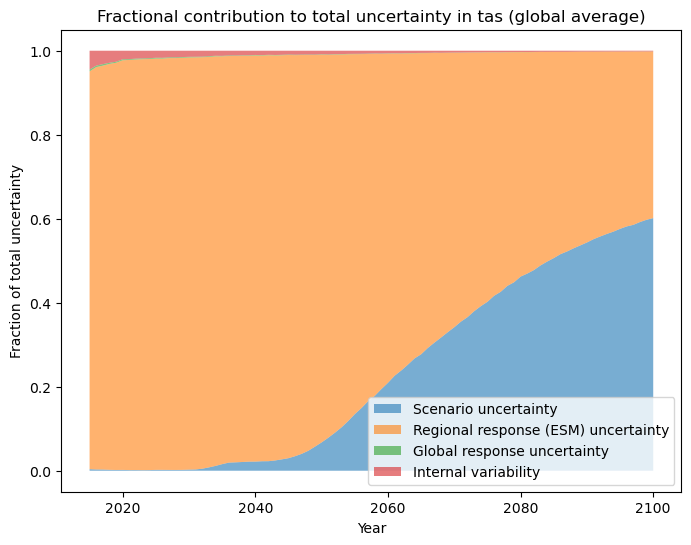

In [4]:
# plot across-scenario regional uncertainty
u_regional_df = xr.open_dataset(f"{processed_dir}/{plot_var}_cross-scenario_meteor_regional_across-scenario-uncertainty.nc")
# computing the total variance as the sum of the individual variances
u_regional_df['var_total'] = u_regional_df['var_scenario'] + u_regional_df['var_esm'] + u_regional_df['var_global'] + u_regional_df['var_int']

sel_region = -1  # global
plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_regional_df['var_scenario'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
esm_uncertainty = u_regional_df['var_esm'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_regional_df['var_global'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_regional_df['var_int'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_regional_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title(f'Fractional contribution to total uncertainty in {plot_var} (global average)')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()

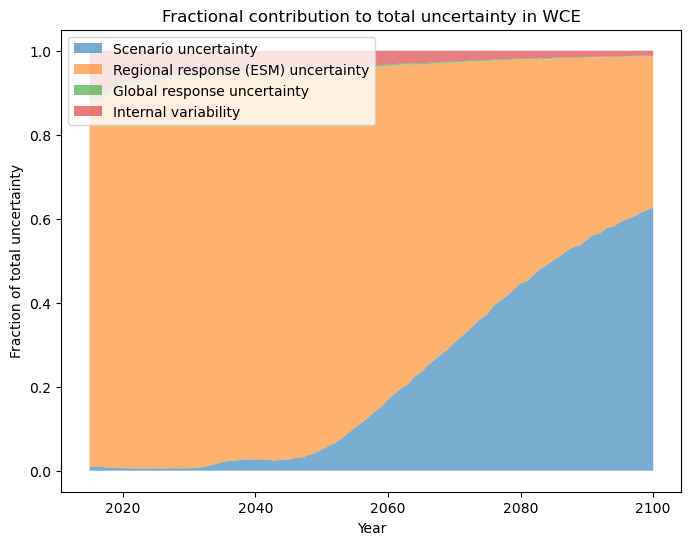

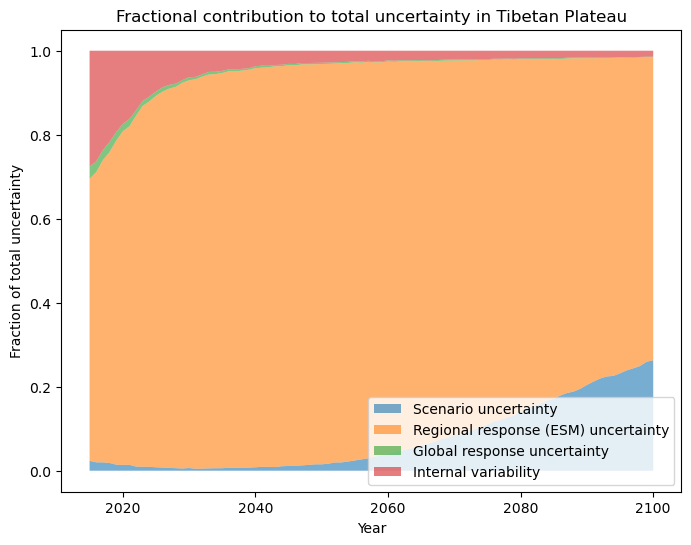

In [5]:
# the resulting plot can vary by region and in, particular,
# the smallter the region, the larger the contribution of internal variability
sel_region = 17  # CENTRAL EUROPE
plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_regional_df['var_scenario'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
esm_uncertainty = u_regional_df['var_esm'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_regional_df['var_global'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_regional_df['var_int'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_regional_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title('Fractional contribution to total uncertainty in WCE')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'upper left')
plt.show()


sel_region = 34  # Tibetan Plateau
plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_regional_df['var_scenario'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
esm_uncertainty = u_regional_df['var_esm'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_regional_df['var_global'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_regional_df['var_int'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_regional_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title('Fractional contribution to total uncertainty in Tibetan Plateau')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()


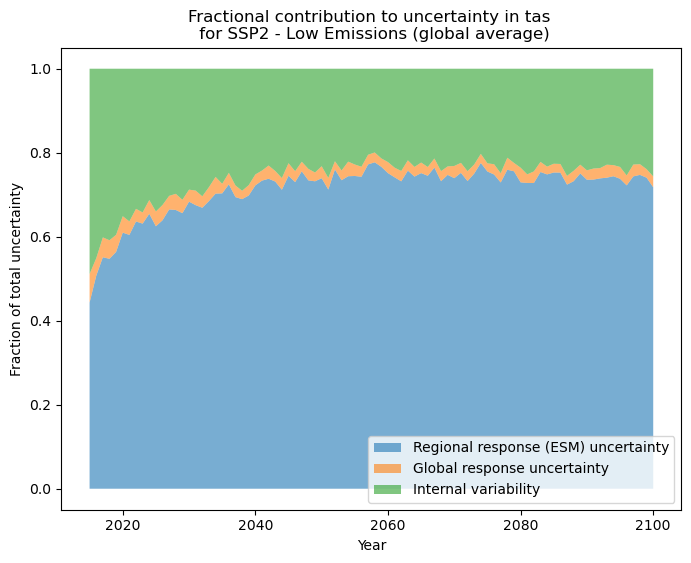

In [6]:
# plot within scenario uncertainty
u_grid_df = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_regional_uncertainty.nc")
# computing the total variance as the sum of the individual variances
u_grid_df['var_total'] =  u_grid_df['var_esm'] + u_grid_df['var_global'] + u_grid_df['var_int']

plt.figure(figsize=(8, 6))

sel_region = -1 #global
# Calculate fractional contributions
esm_uncertainty = u_grid_df['var_esm'].sel(mask=sel_region) / u_grid_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_grid_df['var_global'].sel(mask=sel_region) / u_grid_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_grid_df['var_int'].sel(mask=sel_region) / u_grid_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_grid_df['year'], 0, esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_grid_df['year'], esm_uncertainty, esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_grid_df['year'], esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title(f'Fractional contribution to uncertainty in {plot_var} \n for {scenario_list[s_idx]} (global average)')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()

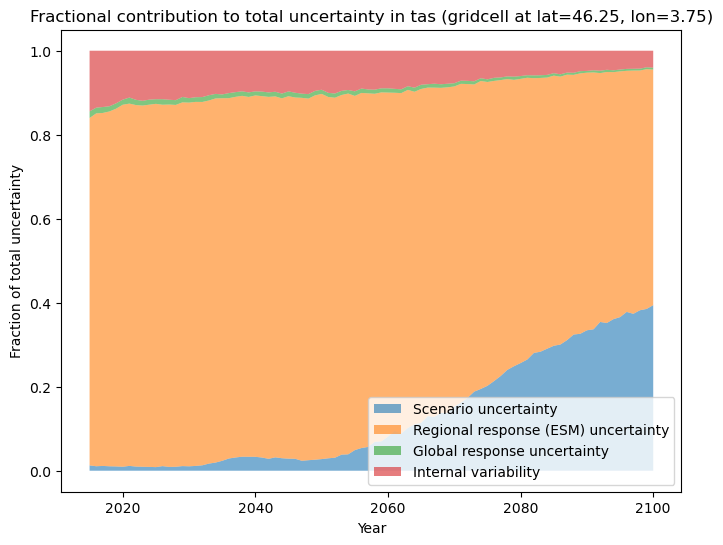

In [7]:
# plot across-scenario gridcell uncertainty
u_gridcell_df = xr.open_dataset(f"{processed_dir}/{plot_var}_cross-scenario_meteor_gridcell_across-scenario-uncertainty.nc")
# computing the total variance as the sum of the individual variances
u_gridcell_df['var_total'] = u_gridcell_df['var_scenario'] + u_gridcell_df['var_esm'] + u_gridcell_df['var_global'] + u_gridcell_df['var_int']

plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_gridcell_df['var_scenario'].sel(lat=sel_lat, lon=sel_lon) / u_gridcell_df['var_total'].sel(lat=sel_lat, lon=sel_lon)
esm_uncertainty = u_gridcell_df['var_esm'].sel(lat=sel_lat, lon=sel_lon) / u_gridcell_df['var_total'].sel(lat=sel_lat, lon=sel_lon)
glob_uncertainty = u_gridcell_df['var_global'].sel(lat=sel_lat, lon=sel_lon) / u_gridcell_df['var_total'].sel(lat=sel_lat, lon=sel_lon)
int_uncertainty = u_gridcell_df['var_int'].sel(lat=sel_lat, lon=sel_lon) / u_gridcell_df['var_total'].sel(lat=sel_lat, lon=sel_lon)

# Stack the uncertainties
plt.fill_between(u_gridcell_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_gridcell_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_gridcell_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_gridcell_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title(f'Fractional contribution to total uncertainty in {plot_var} (gridcell at lat={sel_lat}, lon={sel_lon})')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()

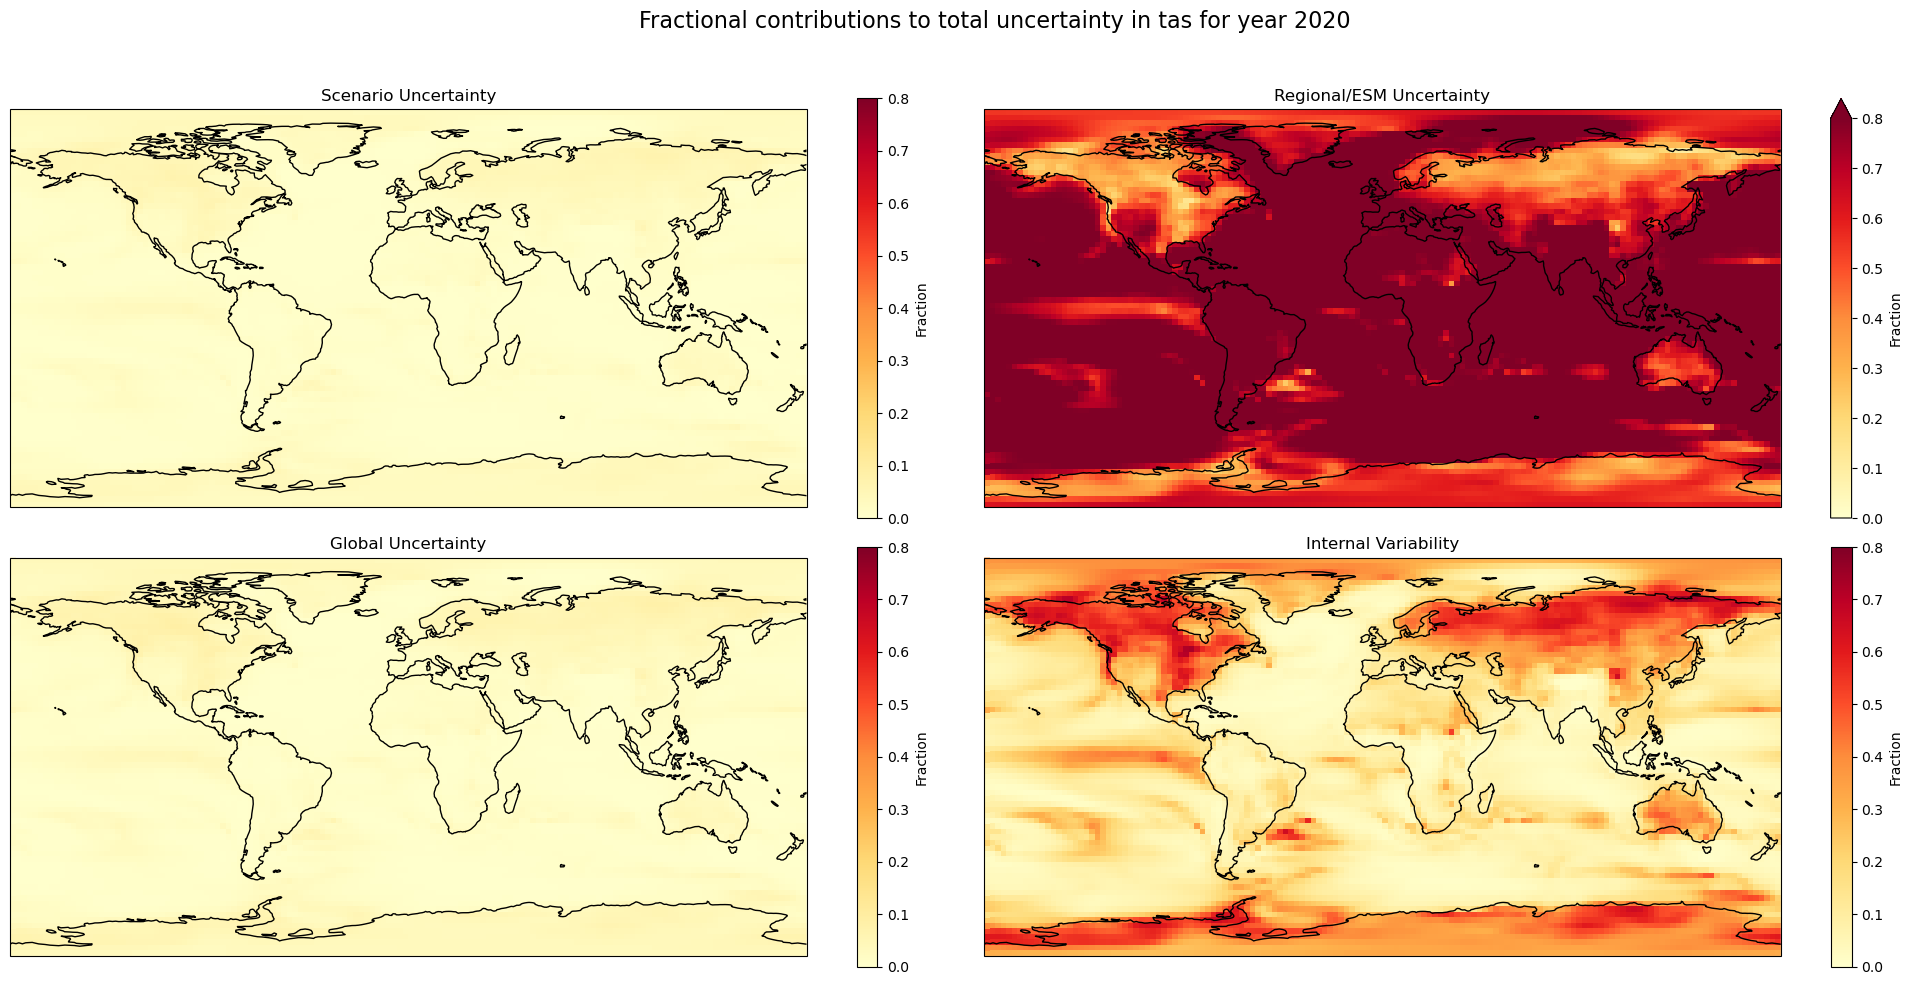

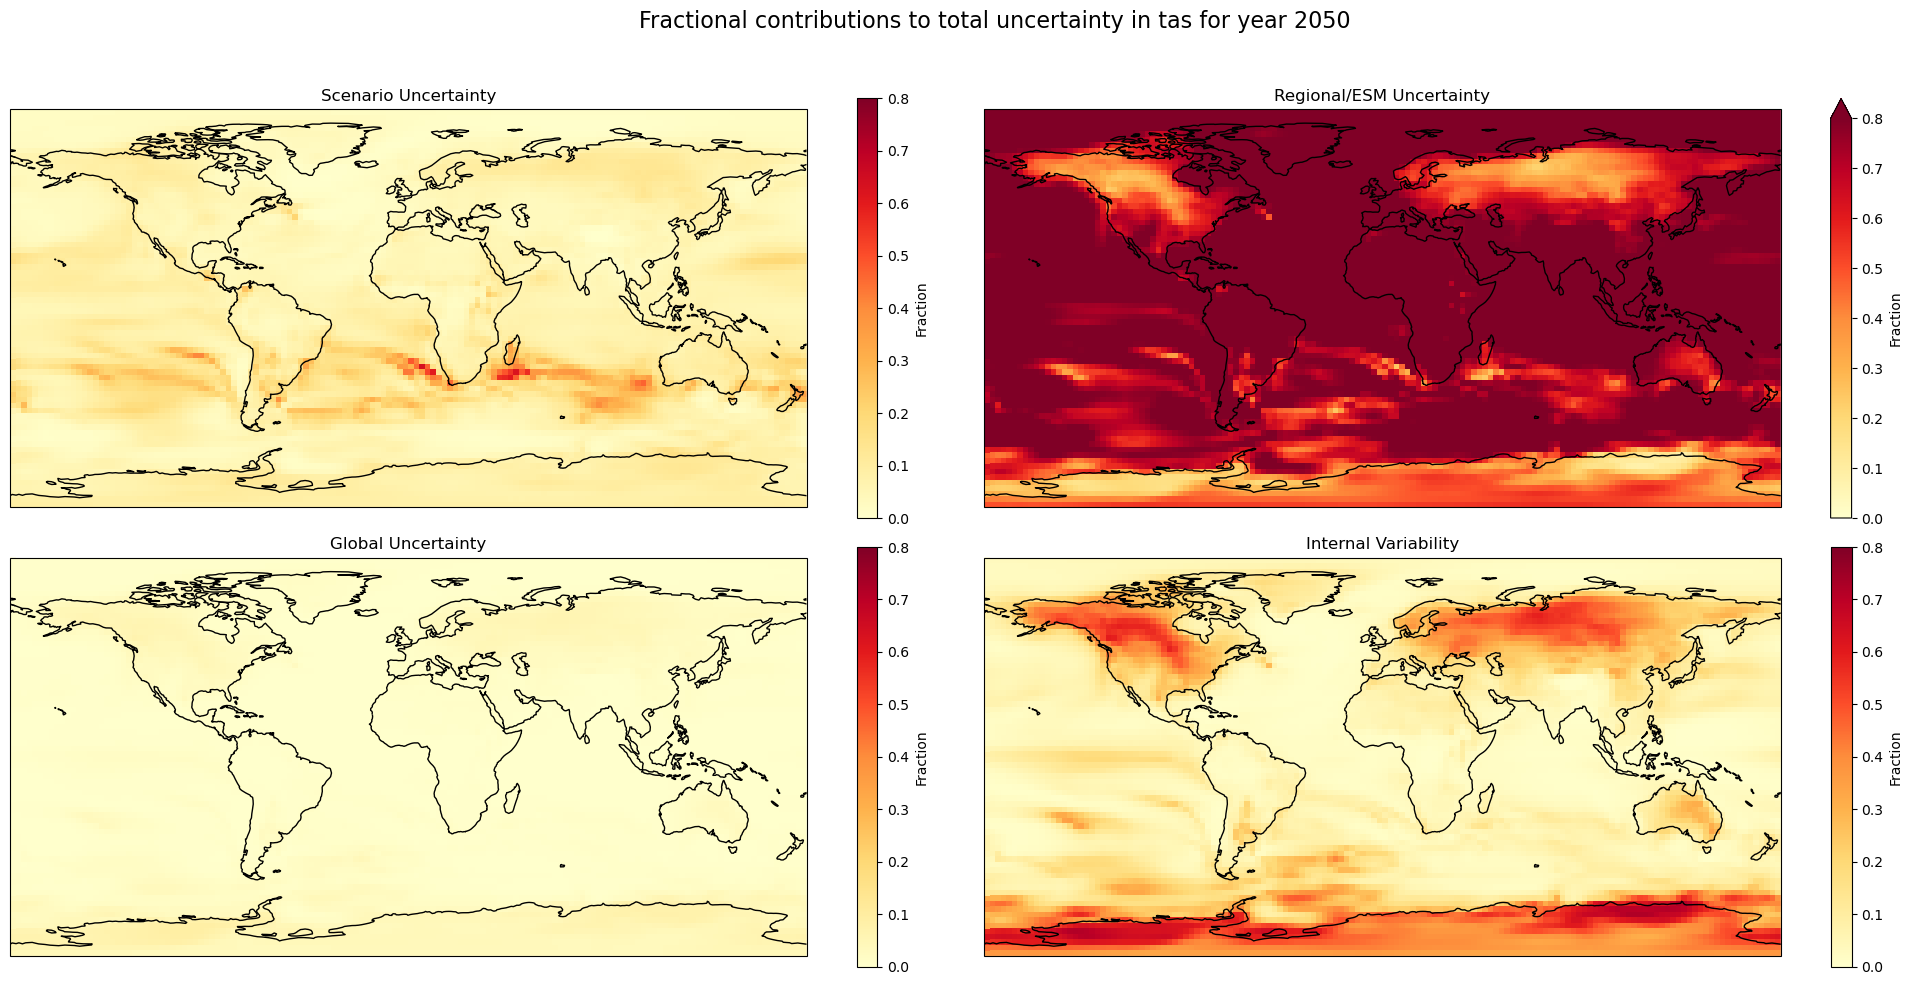

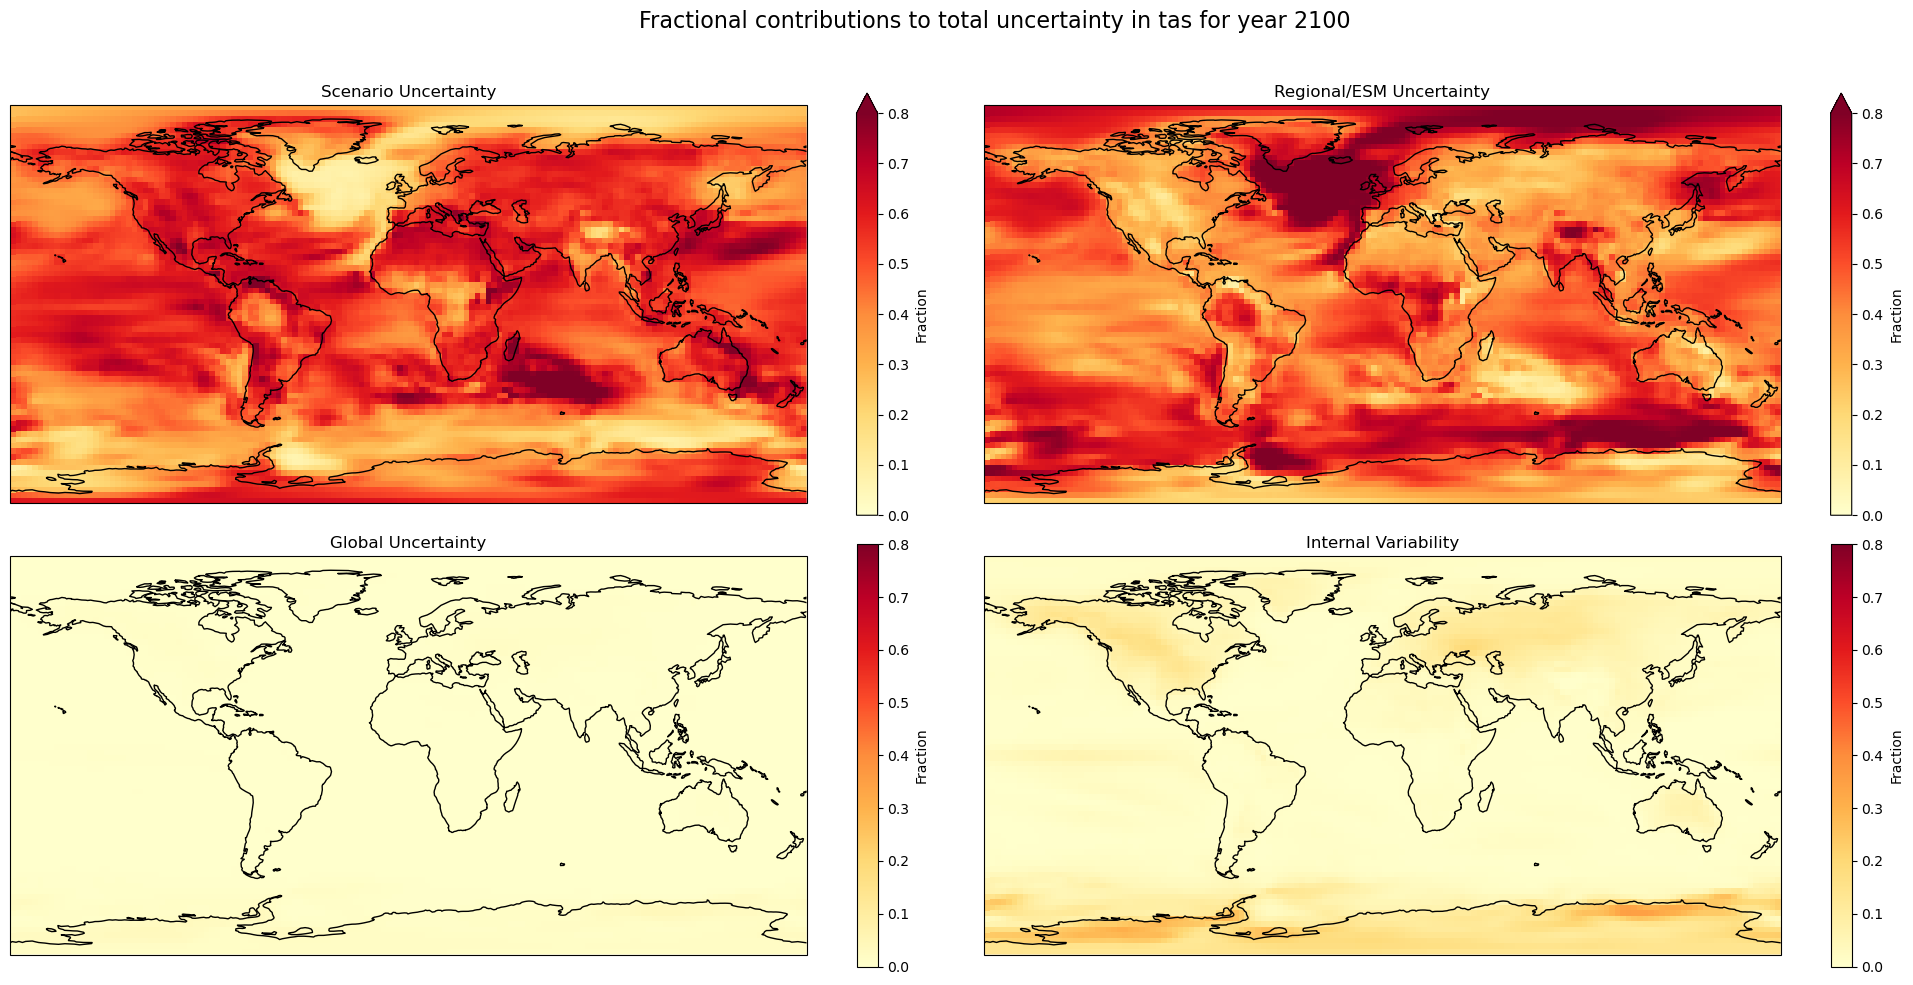

In [8]:
# we can use the grid-cell level data to plot contributions on
# a map and investigate how these maps evolve over time
for sel_year in [2020, 2050, 2100]:
    fig, axes = plt.subplots(2, 2, figsize=(20, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    fractional_contributions = ['var_scenario', 'var_esm', 'var_global', 'var_int']
    titles = ['Scenario Uncertainty', 'Regional/ESM Uncertainty', 'Global Uncertainty', 'Internal Variability']
    cmaps = ['YlOrRd']*4

    for ax, var, title, cmap in zip(axes.flat, fractional_contributions, titles, cmaps):
        data = (u_gridcell_df[var].sel(year=sel_year) / u_gridcell_df['var_total'].sel(year=sel_year))
        data.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=0,
            vmax=0.8,
            cbar_kwargs={"label": "Fraction"}
        )
        ax.coastlines()
        ax.set_title(title)

    fig.suptitle(f'Fractional contributions to total uncertainty in {plot_var} for year {sel_year}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for the suptitle
    plt.show()

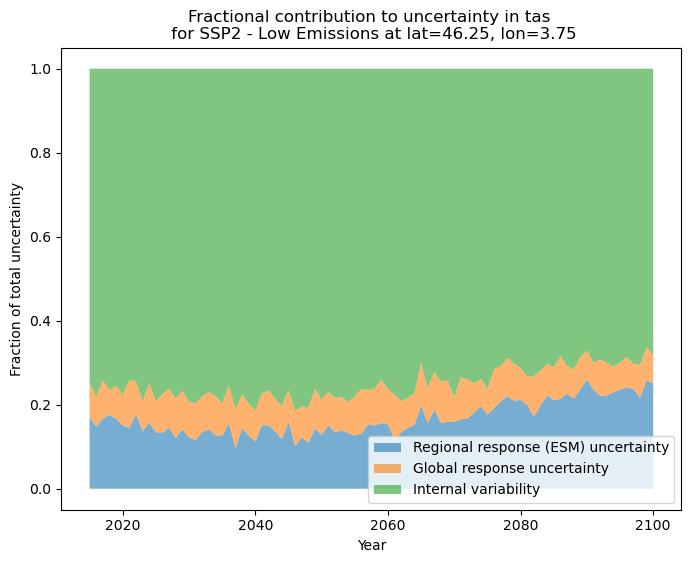

In [9]:
# plot within scenario uncertainty
u_grid_df = xr.open_dataset(f"{processed_dir}/{plot_var}_{scenarios_short[s_idx]}_meteor_gridcell_uncertainty.nc")
# computing the total variance as the sum of the individual variances
u_grid_df['var_total'] =  u_grid_df['var_esm'] + u_grid_df['var_global'] + u_grid_df['var_int']

plt.figure(figsize=(8, 6))

# Calculate fractional contributions
esm_uncertainty = u_grid_df['var_esm'].sel(lat=sel_lat, lon=sel_lon) / u_grid_df['var_total'].sel(lat=sel_lat, lon=sel_lon)
glob_uncertainty = u_grid_df['var_global'].sel(lat=sel_lat, lon=sel_lon) / u_grid_df['var_total'].sel(lat=sel_lat, lon=sel_lon)
int_uncertainty = u_grid_df['var_int'].sel(lat=sel_lat, lon=sel_lon) / u_grid_df['var_total'].sel(lat=sel_lat, lon=sel_lon)

# Stack the uncertainties
plt.fill_between(u_grid_df['year'], 0, esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_grid_df['year'], esm_uncertainty, esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_grid_df['year'], esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title(f'Fractional contribution to uncertainty in {plot_var} \n for {scenario_list[s_idx]} at lat={sel_lat}, lon={sel_lon}')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()
